# **Breast Cancer Diagnosis: Benign vs Malignant using Logistic Regression**

In this project, the **Breast Cancer Wisconsin (Diagnostic) Dataset** has been selected from the recommended `AML-BASIC datasets` to perform a binary classification task. This dataset consists of a total of **569 samples**, where each sample includes **30 numerical features** that describe the characteristics of cell nuclei, such as radius, texture, and smoothness. The data is obtained from **Fine Needle Aspiration (FNA)** biopsies of breast masses, which are commonly used in medical diagnostics.

The main objective of this project is to classify tumors into two categories: **benign** and **malignant**  using **logistic regression**. This classification task is important in the medical domain, as accurate diagnosis can assist in early detection and treatment planning.

Several challenges are considered during this analysis. First, the dataset contains multiple related features, including mean values, standard errors, and worst-case measurements, which may introduce redundancy and correlation among variables. Proper handling of these relationships is necessary to ensure effective model performance. Second, the dataset exhibits a moderate class imbalance, with **357 benign** cases and **212 malignant** cases, which may influence the model's predictions if not properly addressed.

To tackle these challenges, a complete machine learning workflow is implemented in this project. This includes defining the prediction task, performing data exploration, comparing baseline approaches, building a logistic regression model, and interpreting the results. The notebook is structured using a combination of Markdown description and executable code blocks to ensure clarity, readability, and reproducibility of the analysis.

## **Objectives and Problem Statement**


In this study, it is assumed that the morphological characteristics of breast cell nuclei play a significant role in determining whether a tumor is benign or malignant. Since these features capture important structural properties such as size, shape, and texture, they are expected to have a strong relationship with the diagnosis outcome.

The primary objective of this project is to apply a machine learning approach, specifically logistic regression, to classify tumors based on the 30 extracted features available in the dataset. The model aims to learn patterns from these features and accurately distinguish between benign and malignant cases.

To evaluate the effectiveness of the model, a binary classification approach is used. In addition, a `Dummy Classifier` is included as a baseline model. This baseline serves as a reference point, allowing us to compare whether the logistic regression model performs better than a simple strategy that makes predictions without learning from the data.

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

## **Load Dataset and Column name**

In [2]:
# Load Dataset
df= pd.read_csv ("wdbc.data")
df.head()

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [3]:
# Column names
column_names = [
    'ID', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Load CSV file and check if the data are displayed correctly
df = pd.read_csv("wdbc.data", header=None, names=column_names)
df.head()

,ID,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Description**
* The feature names used here are derived from the `wdbc.names` file, which is available in the GitHub repository.
* These names are not originally included in the dataset, so they are manually assigned during data loading.
* The attributes are grouped into three sections: the first 10 columns represent mean values, the next 10 correspond to standard error (SE), and the last 10 describe the worst (maximum) measurements.

## **Exploratory Data Analysis (EDA)**

In [4]:
# Encoding Target Variable (M=1, B=0)
df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})

**Description**

The target column `diagnosis` is transformed into numerical form where **M (malignant)** is mapped to 1 and **B (benign)** is mapped to 0, making it suitable for machine learning models.

In [5]:
# Dataset Overview and Data Quality Check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

**Description** 
* The dataset contains 569 records for every column, confirming that there are no missing values.
* Data types are appropriate; most features are float64, while diagnosis is already in numeric form after encoding.

In [6]:
# Statistical Summary of Features
df.describe()

,ID,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**Description**

* Features are on different scales, e.g., `area_worst` (>4000) vs `smoothness_mean` (<0.2), showing high variation in values.
This confirms heterogeneous feature scaling, so **standardization** is required before model training.
* The dataset appears clean and well-structured, with no obvious extreme outliers based on min, max, and quartile values.
* Features like `radius_mean` and `texture_worst` show realistic biological variation, indicating consistent data distribution.
* The target variable (diagnosis) is fairly balanced, containing a good mix of benign and malignant cases.
* It also indicates that there are no abnormal extreme values, as features such as `area_mean` (max = 2501.0), `area_worst` (max = 4254.0), and `perimeter_worst` (max = 251.2) remain within a realistic range for breast cancer measurements, suggesting the data is biologically consistent.

# **Feature-wise Data Distribution (Histograms)**
To understand how individual features are distributed, histograms are plotted for selected variables.

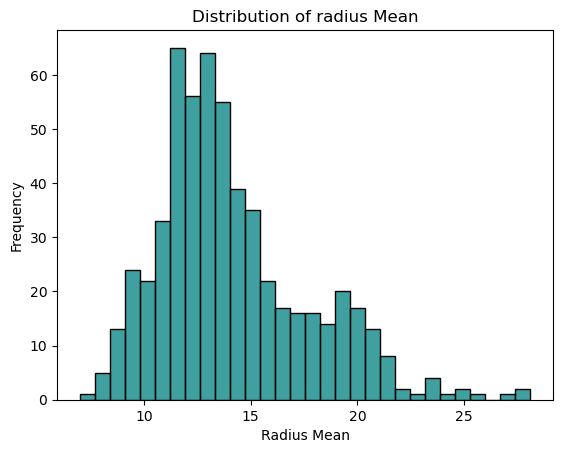

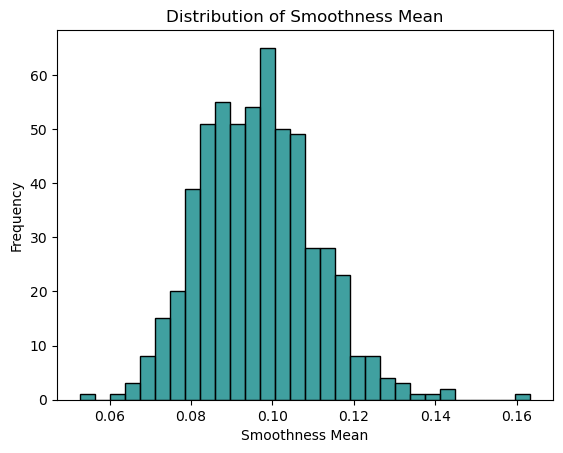

In [7]:
# Distribution of radius_mean feature
plt.figure()
sns.histplot(df['radius_mean'], bins=30 , color="teal")
plt.title("Distribution of radius Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Frequency")
plt.savefig("radius_mean_hist.png", dpi=300)
plt.show()

# Distribution of smoothness_mean feature
plt.figure()
sns.histplot(df['smoothness_mean'], bins=30 , color="teal")
plt.title("Distribution of Smoothness Mean")
plt.xlabel("Smoothness Mean")
plt.ylabel("Frequency")
plt.savefig("smoothness_mean_hist.png", dpi=300)
plt.show()

**Description**

* The `radius_mean` distribution is mostly concentrated between **10 and 17**, with a slight right skew and a few higher values above **25**, indicating limited larger cases.
* The `smoothness_mean` distribution is tightly grouped between **0.06 and 0.16**, showing a more stable and near-normal pattern with very few extreme values.
* Overall, the plots show clear differences in feature scales, highlighting the need for **standardization** before model building.

# **Distribution of Diagnosis Classes (Class imbalance Analysis)**

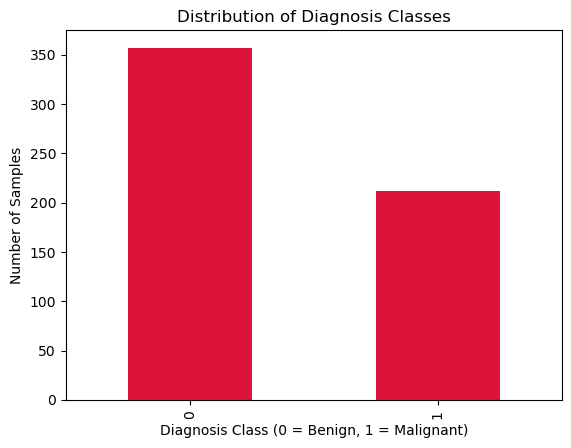

diagnosis
0    357
1    212
Name: count, dtype: int64


In [8]:
# Checking how the target classes are distributed
label_counts = df['diagnosis'].value_counts()

label_counts.plot(kind='bar' , color="crimson")
plt.title("Distribution of Diagnosis Classes")
plt.xlabel("Diagnosis Class (0 = Benign, 1 = Malignant)")
plt.ylabel("Number of Samples")
plt.savefig("diagnosis_class_distribution.png", dpi=300)
plt.show()

# Display exact counts
print(label_counts)

**Description**

The target variable diagnosis shows an uneven distribution, with more benign (0) cases than malignant (1).
This indicates a class imbalance in the dataset.
To handle this, `class weights` **(e.g., class_weight='balanced')** or resampling techniques can be used during model training to reduce bias toward the majority class.

# **Feature Correlation Analysis Using Heatmap**

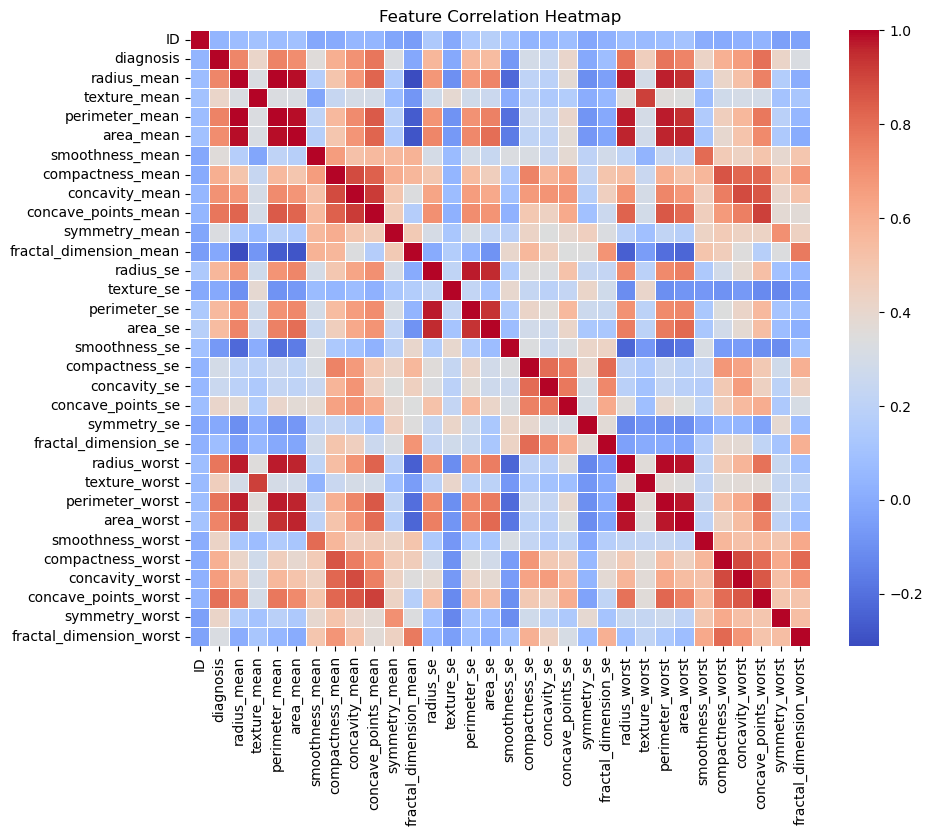

In [9]:
# Correlation matrix for numerical features
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.savefig("feature_correlation_heatmap.png", dpi=300)
plt.show()

**Description**

* The **heatmap** reveals strong correlations among several features, particularly `radius_mean`, `perimeter_mean`, and `area_mean`, showing overlapping information.
* Similar correlations are also observed between mean and worst features (e.g., `radius_mean` with `radius_worst`).
* This indicates multicollinearity, which may need to be handled using **feature selection** or **regularization**.
* Feature correlation with diagnosis will help in identifying the most relevant predictors for classification.

# **Feature Relationship with Diagnosis**

In [10]:
# Removing ID column as it is not useful for analysis
df_filtered = df.drop(columns=['ID'])

# Calculating correlation of all features with the target variable
target_corr = df_filtered.corr()['diagnosis'].sort_values(ascending=False)

# Displaying features most positively correlated with diagnosis
print("Features most correlated with diagnosis:\n")
print(target_corr.head(6).to_string())

# Displaying features least correlated with diagnosis
print("\nFeatures least correlated with diagnosis:\n")
print(target_corr.tail(6).to_string())

Features most correlated with diagnosis:

diagnosis               1.000000
concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636

Features least correlated with diagnosis:

concavity_se              0.253730
fractal_dimension_se      0.077972
symmetry_se              -0.006522
texture_se               -0.008303
fractal_dimension_mean   -0.012838
smoothness_se            -0.067016


**Description**

* **Pearson correlation** is used to measure the relationship between diagnosis and all numerical features, helping identify which variables are most associated with tumor classification.
* Features related to tumor size and shape, such as `radius_worst`, `perimeter_worst`, and `concave_points_worst`, show a strong positive correlation with the diagnosis label.
* In contrast, features like `smoothness_se` and `fractal_dimension_se` have weak or low correlation with the target variable.
* These less important features are typically controlled during modeling using **regularization techniques (e.g., L2)** to reduce their impact and prevent overfitting.

# **Data Preprocessing and Feature Selection**

**Eliminating Strongly Correlated Features**

In [11]:
# Separate input features and target variable
features = df.drop(columns=['ID', 'diagnosis'])
target = df['diagnosis']

# Compute correlation matrix
correlation_matrix = features.corr().abs()

# Create upper triangle matrix mask
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
upper_triangle = correlation_matrix.where(mask)

# Identify features with correlation greater than threshold (0.9)
high_corr_features = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.9)
]

print("Highly correlated features to be removed:", high_corr_features)

# Drop those features
features = features.drop(columns=high_corr_features)

Highly correlated features to be removed: ['perimeter_mean', 'area_mean', 'concave_points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave_points_worst']


**Description**
* The Pearson correlation matrix revealed that several features with similar biological characteristics (e.g., `perimeter_mean`, `area_mean`) are highly correlated (correlation > 0.9), indicating redundancy.
* To address multicollinearity, strongly correlated features were identified and removed, ensuring that only independent and informative variables were retained.
* Approximately 10 redundant features, including `perimeter_mean`, `area_mean`, and `radius_worst`, were eliminated, leaving a reduced but more effective feature set for model training.

# **Feature Export and Dataset Splitting**

In [12]:
# Define predictors and target variable
X_data = df.drop(columns=['ID', 'diagnosis'])
y_data = df['diagnosis']

# Save processed feature dataset
X_data.to_csv("processed_features.csv", index=False)

# Split dataset into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data,
    test_size=0.25,
    random_state=42,
    stratify=y_data
)

**Description**
* The cleaned feature dataset is exported to a **CSV file** using `to_csv`, allowing it to be reused for further analysis or verification.
* The dataset is then divided into **training** and **testing subsets** using a **75:25** ratio. The `stratify` parameter ensures that the class distribution remains balanced across both sets.
* A fixed `random_state` is applied to guarantee reproducibility of the results.

# **Baseline Model using Dummy Classifier**

In [13]:
# Initialize baseline model with most frequent strategy
baseline_model = DummyClassifier(strategy="most_frequent")

# Train the baseline model
baseline_model.fit(X_train, y_train)

# Generate predictions
baseline_predictions = baseline_model.predict(X_test)

# Evaluate baseline performance
print("Baseline Accuracy:", baseline_model.score(X_test, y_test))
print(classification_report(y_test, baseline_predictions, zero_division=0))

Baseline Accuracy: 0.6293706293706294
              precision    recall  f1-score   support

           0       0.63      1.00      0.77        90
           1       0.00      0.00      0.00        53

    accuracy                           0.63       143
   macro avg       0.31      0.50      0.39       143
weighted avg       0.40      0.63      0.49       143



**Description**

* The **Dummy Classifier** predicts only the majority class (benign), without considering any feature information.
* It achieves an **accuracy of approximately 63%**, which serves as a baseline for evaluating the performance of more advanced models.
* Since the model does not predict any malignant cases, metrics such as **precision** for that class become undefined due to division by zero.
* To handle this, the parameter `zero_division=0` is used, ensuring that such cases return a value of 0 instead of generating warnings.

# **Feature Scaling**

In [14]:
# Initialize the scaler
standardizer = StandardScaler()

# Apply scaling on training data and transform test data
X_train_scaled = standardizer.fit_transform(X_train)
X_test_scaled = standardizer.transform(X_test)

**StandardScaler** is used to normalize the features so that they have a **mean** of **0** and a **standard deviation** of **1**, ensuring comparability across variables with different scales.
The scaler is fitted only on the training data, and the same transformation is applied to the test set to prevent **data leakage**.
This process improves model convergence and supports more stable and interpretable coefficient estimates.

# **Logistic Regression Modeling**

In [15]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)  # Handle class imbalance  # Logistic Regression with L2 (default)
model.fit(X_train_scaled, y_train)  # Train the model using the standardized training features X_train_scaled and labels y_train. 

LogisticRegression(class_weight='balanced', max_iter=1000)

**Description**

* Class imbalance is managed by assigning greater weight to malignant cases and increasing the maximum iterations to ensure proper convergence.

* The model is trained on standardized features `(X_train_scaled)` and `labels (y_train)`, which prevents differences in feature scales from affecting the coefficients.

* Logistic Regression also uses default **L2 regularization**, which controls coefficient size and helps reduce **overfitting**.

# **Model Performance Assessment**

In [16]:
# Predict probabilities for malignant class
y_scores = model.predict_proba(X_test_scaled)[:, 1]

# Apply threshold to get final predictions
y_pred = (y_scores >= 0.5).astype(int)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        90
           1       0.98      0.94      0.96        53

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



**Description**

* The model achieves an overall **accuracy** of approximately **0.97**, which is significantly higher than the **dummy baseline** of **0.63**. This clearly indicates that the model has learned meaningful patterns and performs well on unseen data.

* For **malignant cases (1)**, the model shows strong performance with a **precision** of about **0.98**, **recall** around **0.94**, and an **F1-score** of **0.96**. This suggests that most malignant tumors are correctly identified, with only a small number being missed.

* For **benign cases (0)**, the results are even slightly better, with **precision** near **0.97**, **recall** around **0.99**, and an **F1-score** of **0.98**. This means that benign samples are classified very reliably with minimal errors.

* Overall, the model demonstrates balanced performance across both classes, without showing bias toward either class.

# **Compute Confusion Matrix**

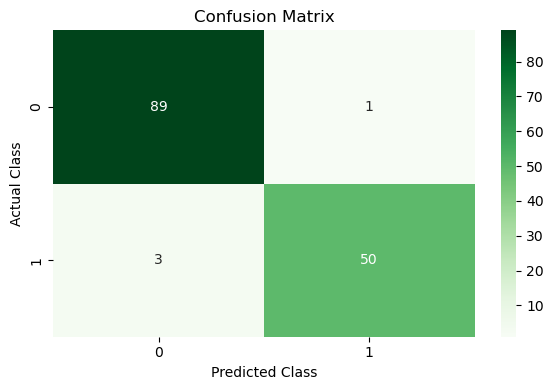

In [17]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

# Save and display plot
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

**Description**

The `confusion matrix` indicates that **89 benign samples** were correctly classified **(true negatives)**, while only **1** was wrongly predicted as **malignant**, reflecting strong accuracy in identifying benign cases.

For malignant samples, **50** were correctly detected **(true positives)**, whereas **3** were misclassified as **benign (false negatives)**, showing a very low rate of missed cancer cases.

Overall, the model prioritizes the detection of malignant tumors, which is important in medical applications where minimizing false negatives is crucial.

These results are consistent with the classification report, confirming reliable precision and recall across both classes.

# **ROC-AUC Performance Evaluation**

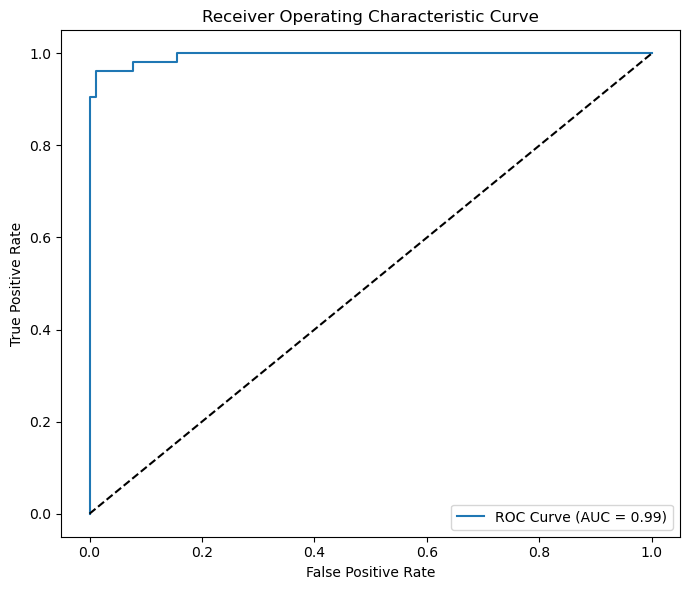

In [18]:
# Predicted probabilities for positive class
scores = model.predict_proba(X_test_scaled)[:, 1]

# ROC curve values
fpr, tpr, _ = roc_curve(y_test, scores)

# AUC score
auc_value = roc_auc_score(y_test, scores)

# Plot ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_value))
plt.plot([0, 1], [0, 1], linestyle="--", color="black")

plt.title("Receiver Operating Characteristic Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")


plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

**Description**

* The **ROC curve** shows the trade-off between the **true positive rate (TPR)** and **false positive rate (FPR)** across different thresholds, reflecting the model’s ability to distinguish malignant from benign cases.

* The diagonal line represents random performance **(AUC = 0.5)**, while curves closer to the top-left corner indicate better classification performance.

* Here, the AUC is approximately **0.99**, which is very close to **1**, demonstrating excellent discriminatory power and a performance level far superior to a baseline model.

* Combined with the confusion matrix, the results confirm a **low false positive rate** and effective detection of malignant cases, making the model suitable for medical diagnosis tasks.

# **Conclusion**

* This study is based on a **breast cancer diagnostic dataset**. From the exploratory data analysis (EDA), it was found that the features have widely different scales and the dataset is imbalanced, which makes feature standardization and class weight adjustment essential for effective modeling.

* The **Dummy Baseline model**, which only considers class distribution, **achieved an accuracy of about 63%**. This is considerably lower than the machine learning model, showing the clear advantage of using predictive algorithms over simple baseline approaches.

* After applying preprocessing steps and addressing class imbalance, the **Logistic Regression model achieved nearly 97% accuracy** on the test data, with an **AUC close to 1**. This performance is much better than random guessing (AUC = 0.5) and the baseline model, indicating that the model successfully captures meaningful patterns in the dataset.

* The confusion matrix reveals a low number of false negatives overall, although a few malignant cases are still predicted as benign. This limitation could be further reduced by tuning the classification threshold, using resampling techniques, or applying ensemble-based models to improve the balance between sensitivity and specificity.

# **Future Work & Extensions**

Model performance can be further enhanced by exploring advanced classifiers such as **Random Forest** or **Gradient Boosting**, along with hyperparameter tuning for optimization. In addition, applying feature engineering, SMOTE for class imbalance, and cross-validation can improve robustness and generalization, making the model more reliable for real-world use. These advanced techniques can be further explored in an `AML-Advanced project` to build more powerful and reliable predictive models.